El objetivo de este análisis es realizar una análisis exploratorio mñás exhaustivo de los datos una vez se tiene un dataset con todos los datos a utilizar.

In [37]:
import pandas as pd

df = pd.read_parquet('../data/processed/dataset_solar_2023_2024_v1.parquet')
df.head()

,fecha,ano,mes,dia,hora,minuto,ghi,dni,dhi,elevacion_solar,temperatura,velocidad_viento,direccion_viento,humedad_relativa,codigo_ghi,codigo_dni,codigo_dhi
0,2023-01-01 00:00:00,2023,1,1,0,0,0.0,0.0,0.0,0.0,10.0,1.050,117.750,77.0,0,0,0
1,2023-01-01 00:01:00,2023,1,1,0,1,0.0,0.0,0.0,0.0,10.0,1.333,311.500,77.0,0,0,0
2,2023-01-01 00:02:00,2023,1,1,0,2,0.0,0.0,0.0,0.0,10.0,1.100,256.417,77.0,0,0,0
3,2023-01-01 00:03:00,2023,1,1,0,3,0.0,0.0,0.0,0.0,10.0,1.333,290.417,77.0,0,0,0
4,2023-01-01 00:04:00,2023,1,1,0,4,0.0,0.0,0.0,0.0,10.0,1.058,333.667,77.0,0,0,0


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1052640 entries, 0 to 1052639
Data columns (total 17 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   fecha             1052640 non-null  datetime64[us]
 1   ano               1052640 non-null  int64         
 2   mes               1052640 non-null  int64         
 3   dia               1052640 non-null  int64         
 4   hora              1052640 non-null  int64         
 5   minuto            1052640 non-null  int64         
 6   ghi               1040772 non-null  float64       
 7   dni               1040772 non-null  float64       
 8   dhi               1040772 non-null  float64       
 9   elevacion_solar   1052640 non-null  float64       
 10  temperatura       957464 non-null   float64       
 11  velocidad_viento  957464 non-null   float64       
 12  direccion_viento  957464 non-null   float64       
 13  humedad_relativa  957464 non-null   float64       
 1

Se tiene un dataset con más de 1 millón de mediciones y 16 variables a priori, de las cuáles se tienen 3 targets que indican la correcta medición de las irradancias GHI, DNI y DHI. Excepto la variable 'fecha', todas las variables son de tipo int o float. Existen nulos en algunas features relacionadas con irradancias o situación meteorológica, siendo estas últimas las que tienen más nulos con casi 80000 nulos.

In [39]:
numeric_columns = ['ghi', 'dni', 'dhi', 'elevacion_solar', 'temperatura', 'velocidad_viento', 'direccion_viento', 'humedad_relativa']

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
ghi,1040772.0,178.272834,285.576990,0.0,0.000,0.000000,293.800000,2525.500000
dni,1040772.0,228.888275,341.553291,0.0,0.000,0.000000,537.917000,1083.250000
dhi,1040772.0,70.152911,135.608487,0.0,0.000,0.000000,80.636000,1153.000000
elevacion_solar,1052640.0,16.126797,21.204923,0.0,0.000,0.452718,29.988567,76.031723
temperatura,957464.0,19.952180,7.900019,-50.0,14.200,19.370000,25.125000,43.450000
velocidad_viento,957464.0,1.909278,1.414230,0.0,0.933,1.627000,2.608000,19.442000
direccion_viento,957464.0,178.340605,97.672695,0.0,74.250,199.083000,248.750000,355.000000
humedad_relativa,957464.0,57.306242,22.061682,0.0,39.917,59.083000,76.000000,95.000000


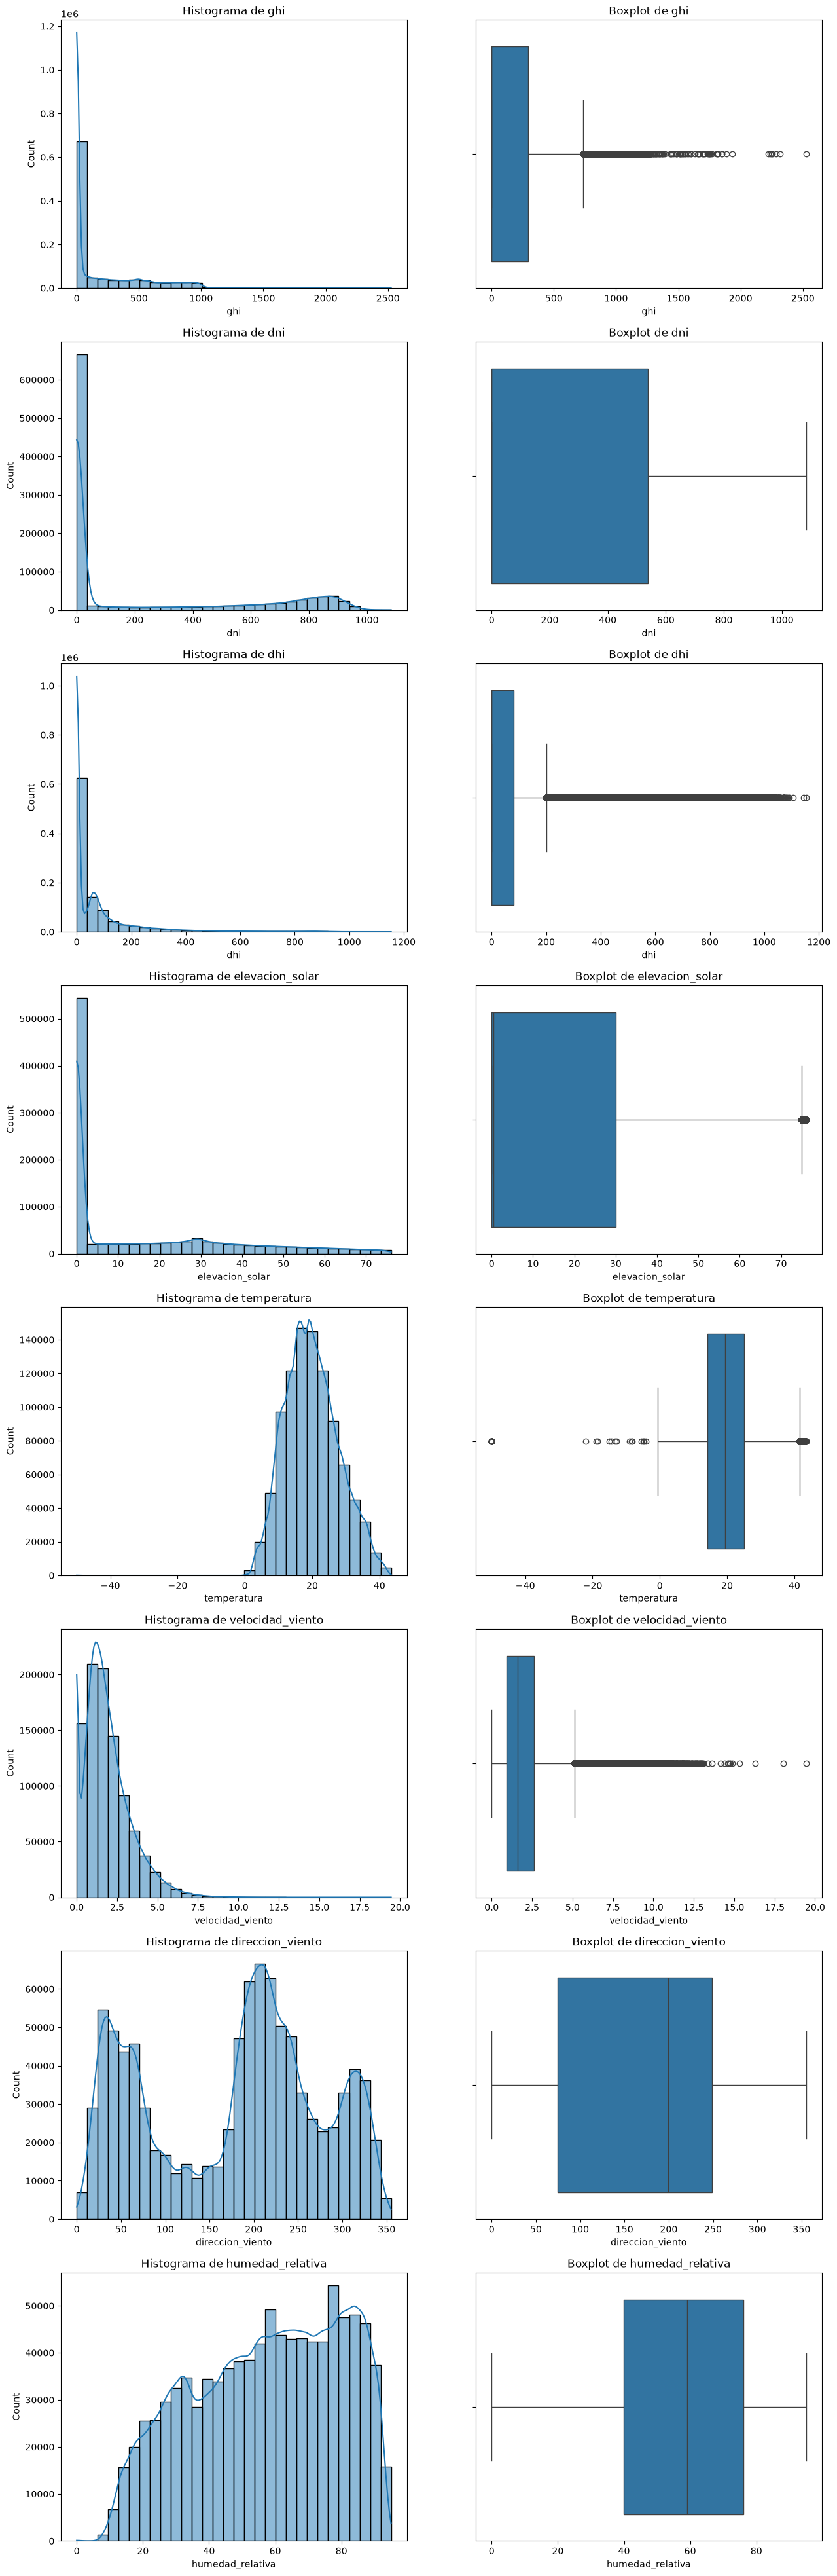

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_hist_box(df, numeric_columns):
    plt.figure(figsize=(15, 50))
    count = 1

    for col in numeric_columns:
        plt.subplot(len(numeric_columns), 2, count)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'Histograma de {col}')
        count += 1

        plt.subplot(len(numeric_columns), 2, count)
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot de {col}')
        count += 1

plot_hist_box(df, numeric_columns)

## Comentarios sobre las variables

* **Irradiancias (`ghi`, `dni` y `dhi`)**: se concentran muchos valores en cero, algo normal por la presencia de registros nocturnos. Durante el día aparecen valores mucho más altos, especialmente en la `dni`. Destacan algunos máximos de `ghi` y `dhi`, ya que parecen poco habituales, por lo que deberían estar asociados a códigos de malos registros.

* **Elevación solar**: también acumula muchos valores cercanos a cero, en línea con las horas nocturnas o con momentos próximos al amanecer y al atardecer. Esto se debe principalmente a que se han establecido como valores nulos valores negativos de elevación del Sol.

* **Temperatura**: sigue una distribución bastante equilibrada y centrada en valores templados. El mínimo de −50 °C destaca claramente y probablemente sea un error de medida o un valor usado para indicar datos ausentes.

* **Velocidad del viento**: predominan las velocidades bajas, aunque hay algunos episodios de viento fuerte que generan una cola hacia valores altos.

* **Dirección del viento**: aparecen varias direcciones dominantes. Al tratarse de una variable circular, es mejor analizarla con una rosa de los vientos que con un boxplot o una media convencional.

* **Humedad relativa**: la mayor parte de los registros se sitúa en niveles medios y altos. Los valores cercanos a cero son poco habituales y sería conveniente revisarlos.

En general, antes de trabajar con los datos podría convenir separar día y noche usando la elevación solar, revisar los valores extremos y estudiar los datos ausentes, especialmente en las variables meteorológicas.


In [41]:
df_2023 = df[df['ano'] == 2023].copy()
df_2024 = df[df['ano'] == 2024].copy()

targets = ['codigo_ghi', 'codigo_dni', 'codigo_dhi']

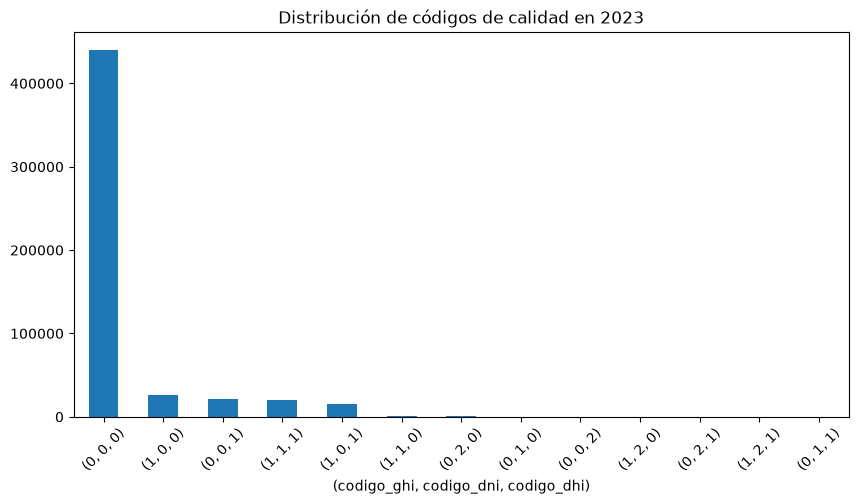

In [42]:
df_2023[targets].value_counts().plot(kind='bar', figsize=(10, 5), title='Distribución de códigos de calidad en 2023')
plt.xlabel('(codigo_ghi, codigo_dni, codigo_dhi)')
plt.xticks(rotation=45)
plt.show()

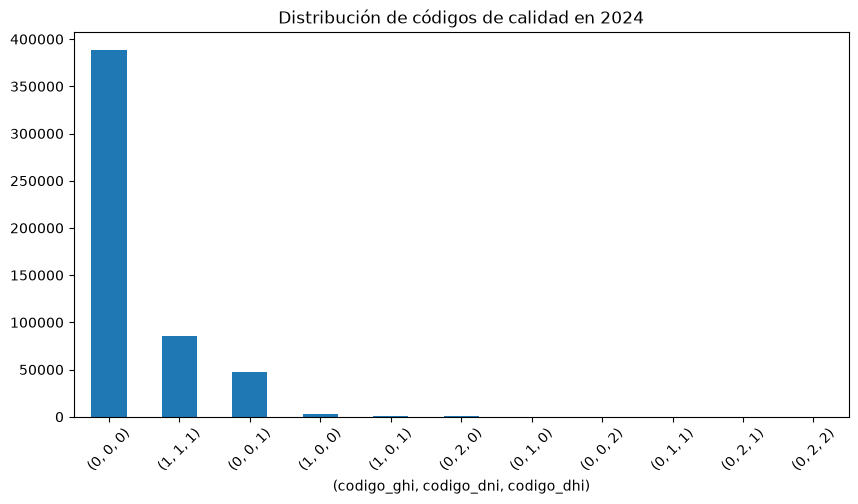

In [43]:
df_2024[targets].value_counts().plot(kind='bar', figsize=(10, 5), title='Distribución de códigos de calidad en 2024')
plt.xlabel('(codigo_ghi, codigo_dni, codigo_dhi)')
plt.xticks(rotation=45)
plt.show()

## Códigos de calidad de las medidas

En ambos años predominan claramente los registros con código **(0, 0, 0)**, por lo que la mayor parte de las medidas de `ghi`, `dni` y `dhi` se consideran correctas y coherentes entre sí.

En **2023** la calidad general es mejor, ya que la proporción de combinaciones con irregularidades es relativamente baja. Los casos más frecuentes después de los datos correctos afectan solo a una componente, sobre todo a la `ghi` o a la `dhi`, mientras que las combinaciones con varios errores simultáneos son poco habituales.

En **2024** disminuye el número de registros completamente correctos y aumentan de forma clara las combinaciones con código 1. Destaca especialmente **(1, 1, 1)**, lo que indica más periodos en los que las tres componentes presentan irregularidades al mismo tiempo. También aumenta **(0, 0, 1)**, asociado a problemas aislados en la `dhi`.

Los códigos relacionados con sombras, identificados con el valor **2**, tienen una presencia muy reducida en ambos años. Por tanto, las anomalías parecen estar más relacionadas con fallos de captación, mantenimiento, desconexiones o medidas inconsistentes que con sombras producidas por una baja elevación solar.


Ahora vamos a obtener la matriz de correlación entre featues numéricas y los targets

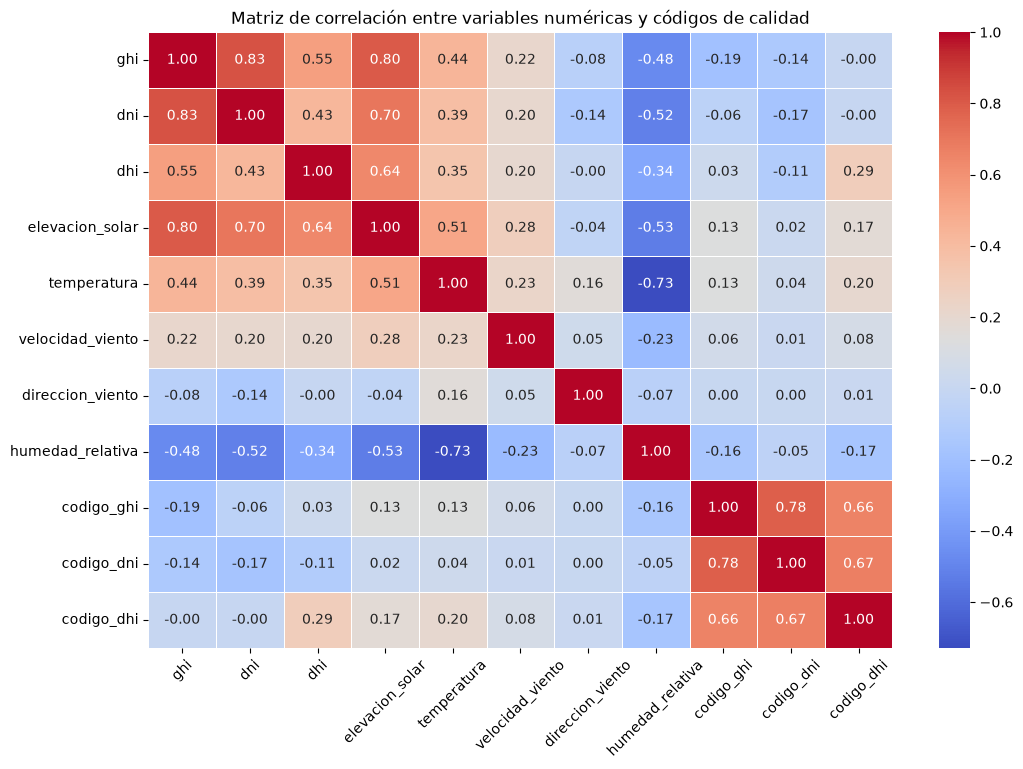

In [44]:
corr = df[numeric_columns + targets].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de correlación entre variables numéricas y códigos de calidad')
plt.xticks(rotation=45)
plt.show()

La variable con mayores correlaciones con las irradancias es la elevación solar seguida de la humedad relativa y la temperatura, sin embargo, ninguna variable tiene una alta correlación con los targets del problema. 

In [45]:
def features_per_time(df, columns, year):
    """
    Obtiene las medias de las columnas especificadas por mes, día y hora para un año específico y genera gráficos de línea.
    
    Parameters:
    - df: dataframe
    - columns: lista de columnas a analizar
    - year: año específico (None para todos)
    """
    if year is not None:
        df_year = df[df['ano'] == year].copy()
        title_suffix = f' - Año {year}'
    else:
        df_year = df.copy()
        title_suffix = ''


    means_per_month = df_year.groupby('mes')[columns].mean()
    means_per_day = df_year.groupby('dia')[columns].mean()
    means_per_hour = df_year.groupby('hora')[columns].mean()

    count = 1
    print(f"Medias por mes, día y hora {title_suffix}:")

    plt.figure(figsize=(15, 40))
    for col in columns:
        
        plt.subplot(len(columns), 3, count)
        plt.plot(means_per_month.index, means_per_month[col], label=col)
        plt.xlabel('Mes')
        plt.ylabel('Media')
        plt.title(f'{col} por Mes')
        plt.legend()
        count += 1

        plt.subplot(len(columns), 3, count)
        plt.plot(means_per_day.index, means_per_day[col], label=col)
        plt.xlabel('Día')
        plt.ylabel('Media')
        plt.title(f'{col} por Día')
        plt.legend()
        count += 1

        plt.subplot(len(columns), 3, count)
        plt.plot(means_per_hour.index, means_per_hour[col], label=col)
        plt.xlabel('Hora')
        plt.ylabel('Media')
        plt.title(f'{col} por Hora')
        plt.legend()
        count += 1

    plt.tight_layout()
    plt.show()


Medias por mes, día y hora  - Año 2023:


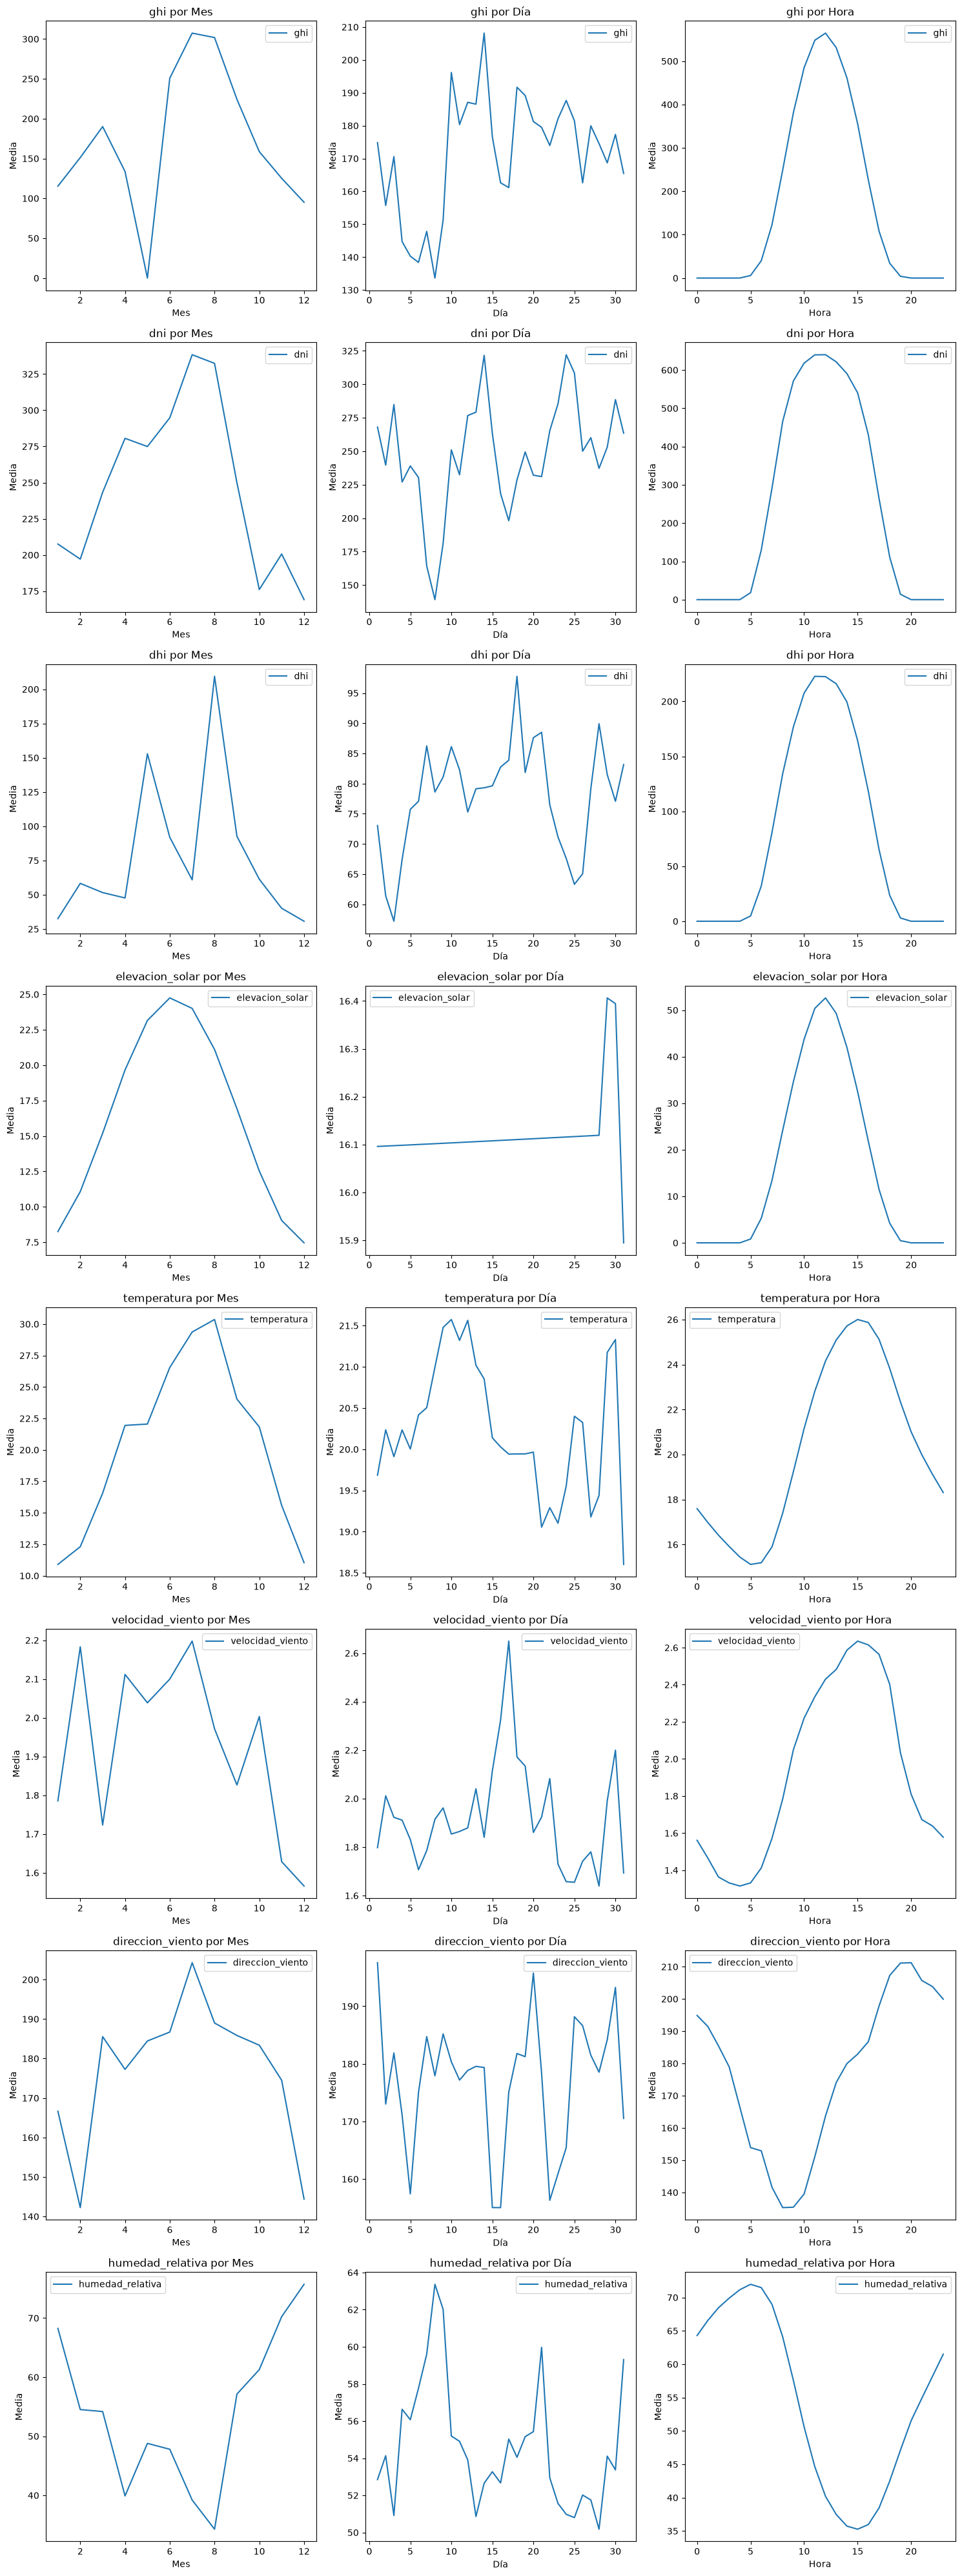

In [46]:
features_per_time(df, numeric_columns, 2023)

- `GHI`, `DNI` y `DHI` siguen un patrón horario similar al de la elevación solar: aumentan tras el amanecer, alcanzan su máximo en las horas centrales y disminuyen al atardecer.

- Las irradiancias son prácticamente nulas durante la noche, por lo que valores elevados con elevación solar igual o inferior a cero pueden indicar mediciones incorrectas.

- `DNI` presenta el patrón más marcado, mientras que `DHI` muestra una evolución más suave y puede verse más afectada por nubosidad y dispersión atmosférica.

- La temperatura aumenta después del amanecer y alcanza su máximo más tarde que la irradiancia, mientras que la humedad relativa sigue un patrón inverso.

- La evolución mensual de las irradiancias debería acompañar, en términos generales, a la elevación solar, aunque puede verse modificada por las condiciones meteorológicas.

- La caída anómala de `GHI` en mayo no coincide con el comportamiento de la elevación solar ni con el resto de variables, por lo que debe revisarse como posible error de registro o preprocesamiento.

- Las tendencias por mes, asociadas a las estaciones del año, como la tendencias por hora, asociadas al momento del día, muestran patrones claros en las variables que no son vistas en las gráficas por día del mes, ya que esta última agrupación mezcla días pertenecientes a meses diferentes, los cuáles deberían registrar valores diferentes más relacionados con la época del año en vez de con el día. De esta manera, puede ser interesante establecer variables que muestren el valor medio a a una hora determinada y en un mes determinado

Medias por mes, día y hora  - Año 2024:


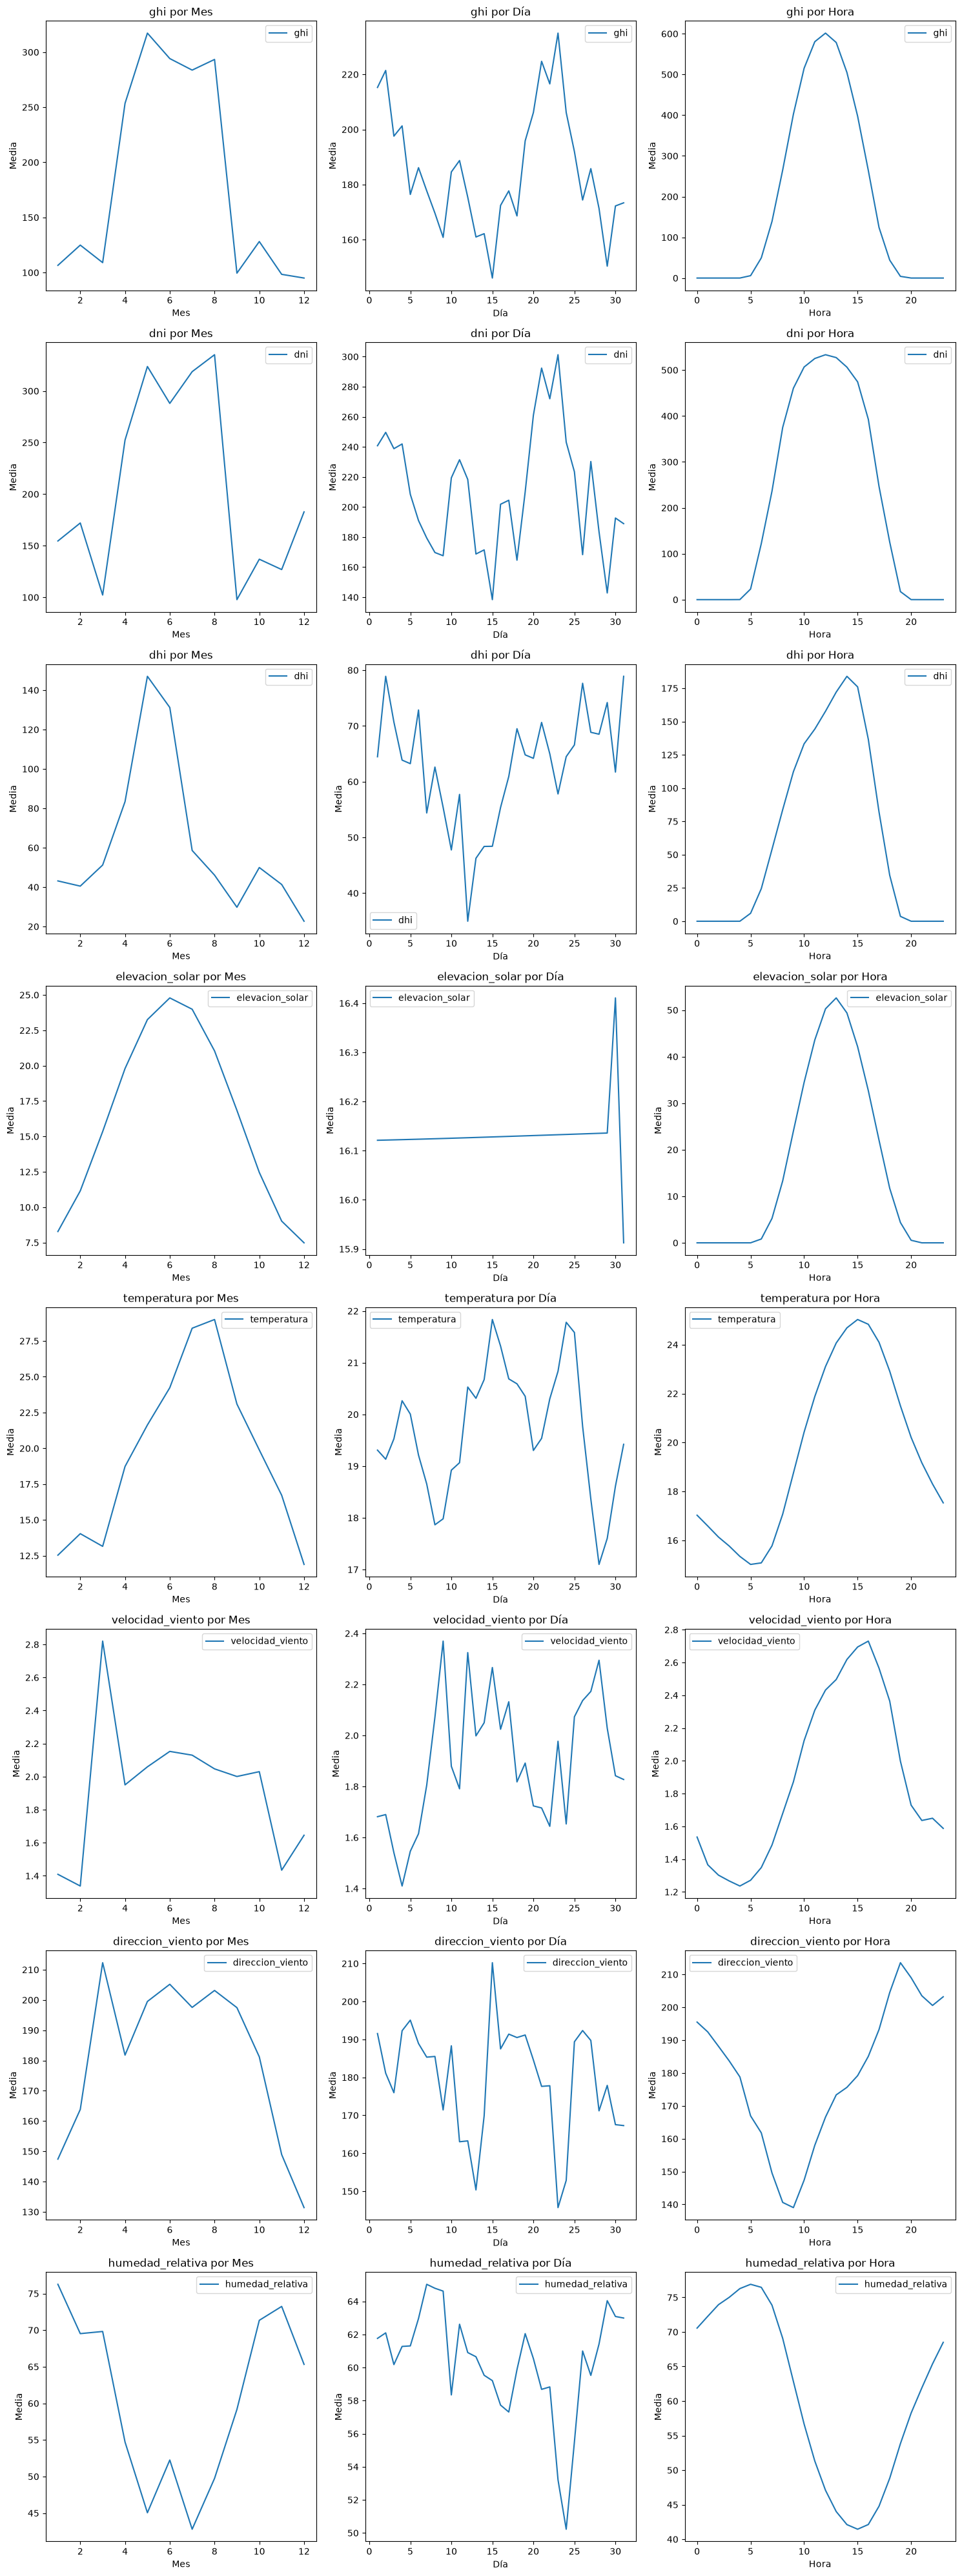

In [47]:
features_per_time(df, numeric_columns, 2024)

## Comparación 2023–2024

- En ambos años, `GHI`, `DNI` y `DHI` presentan un patrón horario muy similar al de la elevación solar: valores nulos durante la noche, aumento tras el amanecer y máximo en las horas centrales del día.

- Los patrones horarios son bastante estables entre años, lo que confirma que la hora y la elevación solar serán variables clave para detectar registros incorrectos.

- En 2023 aparece una anomalía clara en `GHI` durante mayo, con valores prácticamente nulos pese a existir una elevación solar elevada. Esta anomalía no se observa en 2024, cuyo comportamiento mensual es más coherente.

- En 2024, las tres irradiancias muestran una caída muy brusca entre agosto y septiembre. Al afectar simultáneamente a `GHI`, `DNI` y `DHI`, conviene comprobar si existen datos ausentes, registros incompletos o algún cambio en la adquisición.

- La `DNI` presenta un máximo horario mayor en 2023, mientras que la `GHI` alcanza valores algo superiores en 2024. La `DHI` es generalmente más elevada en 2023.

- La temperatura y la humedad mantienen patrones inversos similares en ambos años: la temperatura aumenta durante el día y la humedad disminuye.

- En 2024 la humedad relativa es, en general, más elevada y la velocidad del viento presenta valores algo superiores, especialmente durante las horas centrales.


In [48]:
def analyze_missing_values(df, columns, year=None):
    """
    Analiza los valores ausentes en las columnas especificadas.
    
    Parameters:
    - df: dataframe
    - columns: lista de columnas a analizar
    - year: año específico (None para todos)
    """
    df_filtered = df[df['ano'] == year].copy()
    title_suffix = f' - Año {year}'

    # Contar nulos
    missing_count = df_filtered[columns].isnull().sum()
    missing_pct = (df_filtered[columns].isnull().sum() / len(df_filtered)) * 100
    
    # Tabla resumen
    missing_df = pd.DataFrame({
        'Nulos': missing_count,
        'Porcentaje': missing_pct
    }).sort_values('Nulos', ascending=False)
    
    print(f"Resumen de valores ausentes{title_suffix}:")
    print(missing_df)
    print()
    
    # Visualización
    _, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico de barras
    missing_df['Nulos'].plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title(f'Cantidad de nulos por variable{title_suffix}')
    axes[0].set_xlabel('Número de nulos')
    
    # Gráfico de porcentaje
    missing_df['Porcentaje'].plot(kind='barh', ax=axes[1], color='coral')
    axes[1].set_title(f'Porcentaje de nulos{title_suffix}')
    axes[1].set_xlabel('Porcentaje (%)')
    
    plt.tight_layout()
    plt.show()
    
    # Matriz de correlación de nulos
    missing_matrix = df_filtered[columns].isnull().astype(int)
    if missing_matrix.sum().sum() > 0:  # Si hay nulos
        plt.figure(figsize=(10, 6))
        sns.heatmap(missing_matrix.corr(), annot=True, cmap='RdYlGn_r', fmt='.2f', cbar_kws={'label': 'Correlación'})
        plt.title(f'Correlación entre patrones de nulos{title_suffix}')
        plt.xticks(rotation=45)
        plt.show()

Resumen de valores ausentes - Año 2023:
                  Nulos  Porcentaje
humedad_relativa  20602    3.919711
direccion_viento  20602    3.919711
velocidad_viento  20602    3.919711
temperatura       20602    3.919711
dni                1787    0.339992
dhi                1787    0.339992
ghi                1787    0.339992
elevacion_solar       0    0.000000



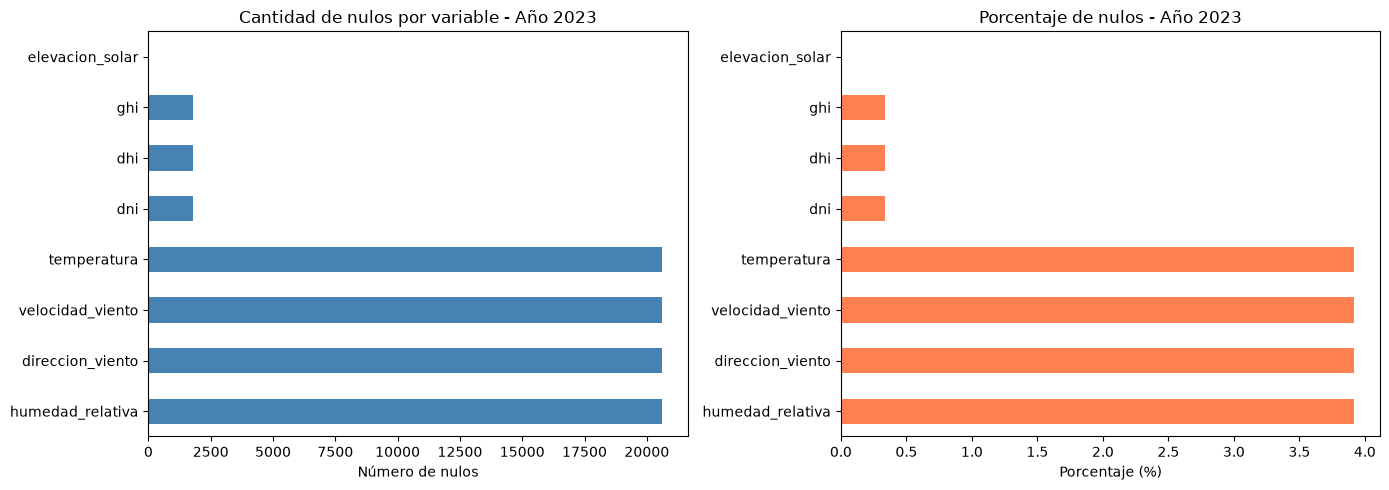

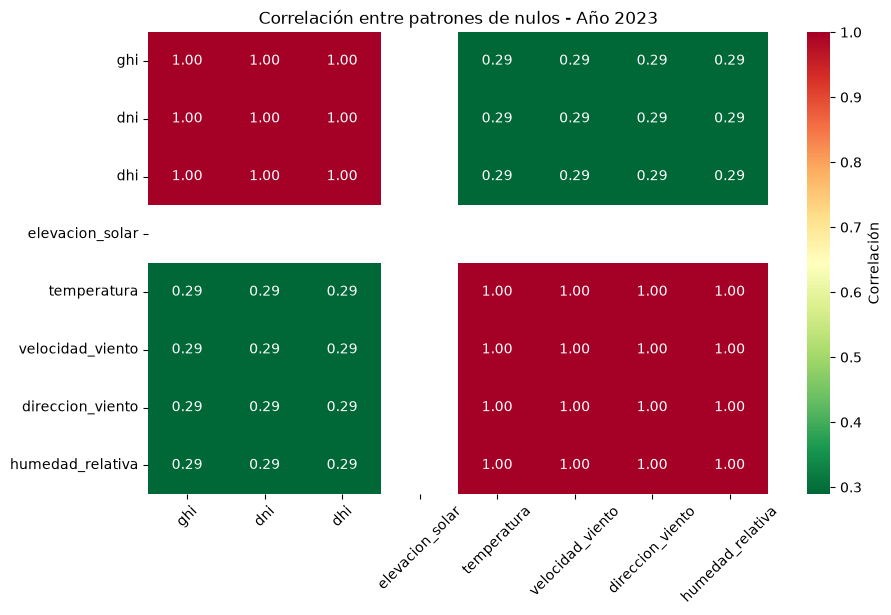

In [49]:
analyze_missing_values(df, numeric_columns, 2023)

Se tienen muchos más valores nulos de variables meteorológicas que de irradancias y se puede comprobar tanto por los valores nulos como con las correlaciones que cuando falta el valor de una variable meteorológica, faltan los valores del resto y lo mismo pasa con las irradancias entre ellas. 

Resumen de valores ausentes - Año 2024:
                  Nulos  Porcentaje
humedad_relativa  74574   14.149590
direccion_viento  74574   14.149590
velocidad_viento  74574   14.149590
temperatura       74574   14.149590
dni               10081    1.912758
dhi               10081    1.912758
ghi               10081    1.912758
elevacion_solar       0    0.000000



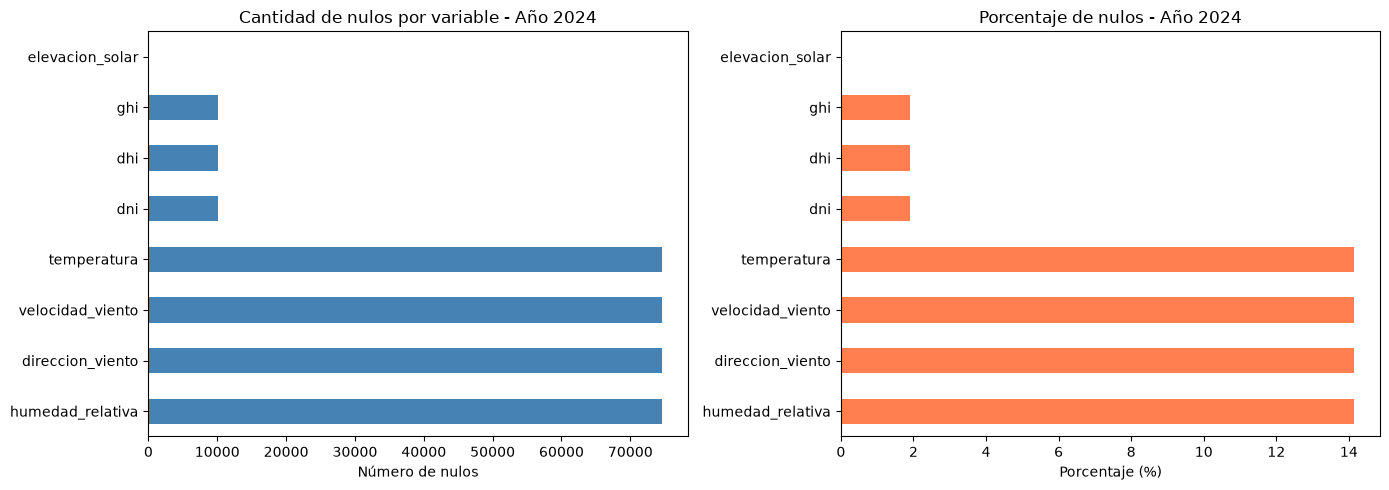

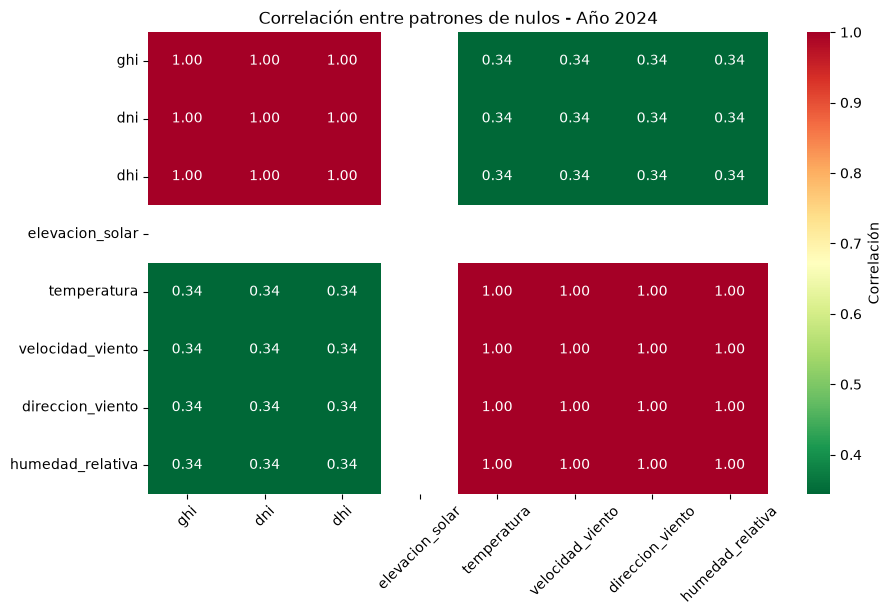

In [50]:
analyze_missing_values(df, numeric_columns, 2024)

Para 2024 tenemos los mismos patrones el triple de ausentes en componentes meteorológicas y casi 6 veces más datos faltantes de irradancias

In [51]:
def analyze_missing_temporal_patterns(df, columns, year=None):
    """
    Analiza los patrones temporales de valores ausentes.
    Muestra nulos por mes y por hora del día.
    
    Parameters:
    - df: dataframe
    - columns: lista de columnas a analizar
    - year: año específico (None para todos)
    """
    if year is not None:
        df_filtered = df[df['ano'] == year].copy()
        title_suffix = f' - Año {year}'
    else:
        df_filtered = df.copy()
        title_suffix = ''
    
    # Crear matriz de nulos
    missing_matrix = df_filtered[columns].isnull().astype(int)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Nulos por mes
    missing_per_month = df_filtered.groupby('mes')[columns].apply(lambda x: x.isnull().sum())
    missing_per_month.plot(ax=axes[0, 0], marker='o')
    axes[0, 0].set_title(f'Valores nulos por mes{title_suffix}')
    axes[0, 0].set_xlabel('Mes')
    axes[0, 0].set_ylabel('Cantidad de nulos')
    axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Porcentaje de nulos por mes
    missing_per_month_pct = (df_filtered.groupby('mes')[columns].apply(lambda x: x.isnull().sum()) / 
                             df_filtered.groupby('mes').size().values.reshape(-1, 1) * 100)
    missing_per_month_pct.plot(ax=axes[0, 1], marker='o')
    axes[0, 1].set_title(f'Porcentaje de nulos por mes{title_suffix}')
    axes[0, 1].set_xlabel('Mes')
    axes[0, 1].set_ylabel('Porcentaje (%)')
    axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Nulos por hora
    missing_per_hour = df_filtered.groupby('hora')[columns].apply(lambda x: x.isnull().sum())
    missing_per_hour.plot(ax=axes[1, 0], marker='o')
    axes[1, 0].set_title(f'Valores nulos por hora del día{title_suffix}')
    axes[1, 0].set_xlabel('Hora')
    axes[1, 0].set_ylabel('Cantidad de nulos')
    axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Porcentaje de nulos por hora
    missing_per_hour_pct = (df_filtered.groupby('hora')[columns].apply(lambda x: x.isnull().sum()) / 
                            df_filtered.groupby('hora').size().values.reshape(-1, 1) * 100)
    missing_per_hour_pct.plot(ax=axes[1, 1], marker='o')
    axes[1, 1].set_title(f'Porcentaje de nulos por hora{title_suffix}')
    axes[1, 1].set_xlabel('Hora')
    axes[1, 1].set_ylabel('Porcentaje (%)')
    axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [52]:
numeric_columns_without_elevacion = numeric_columns.copy()
numeric_columns_without_elevacion.remove('elevacion_solar')

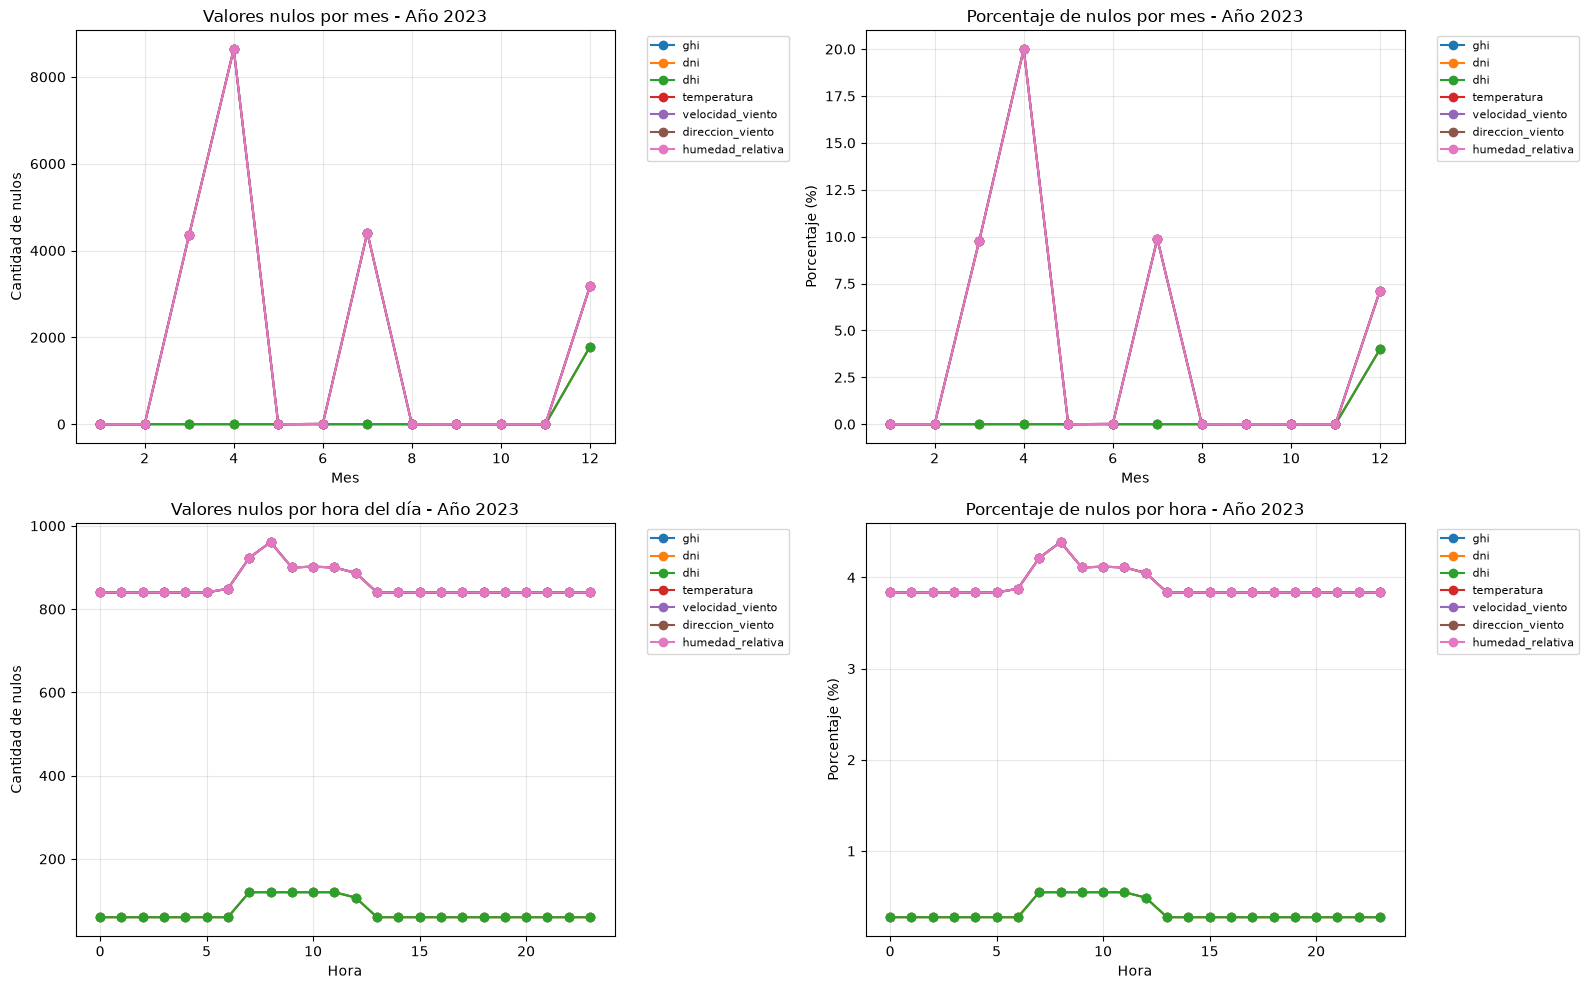

In [53]:
analyze_missing_temporal_patterns(df, numeric_columns_without_elevacion, year=2023)

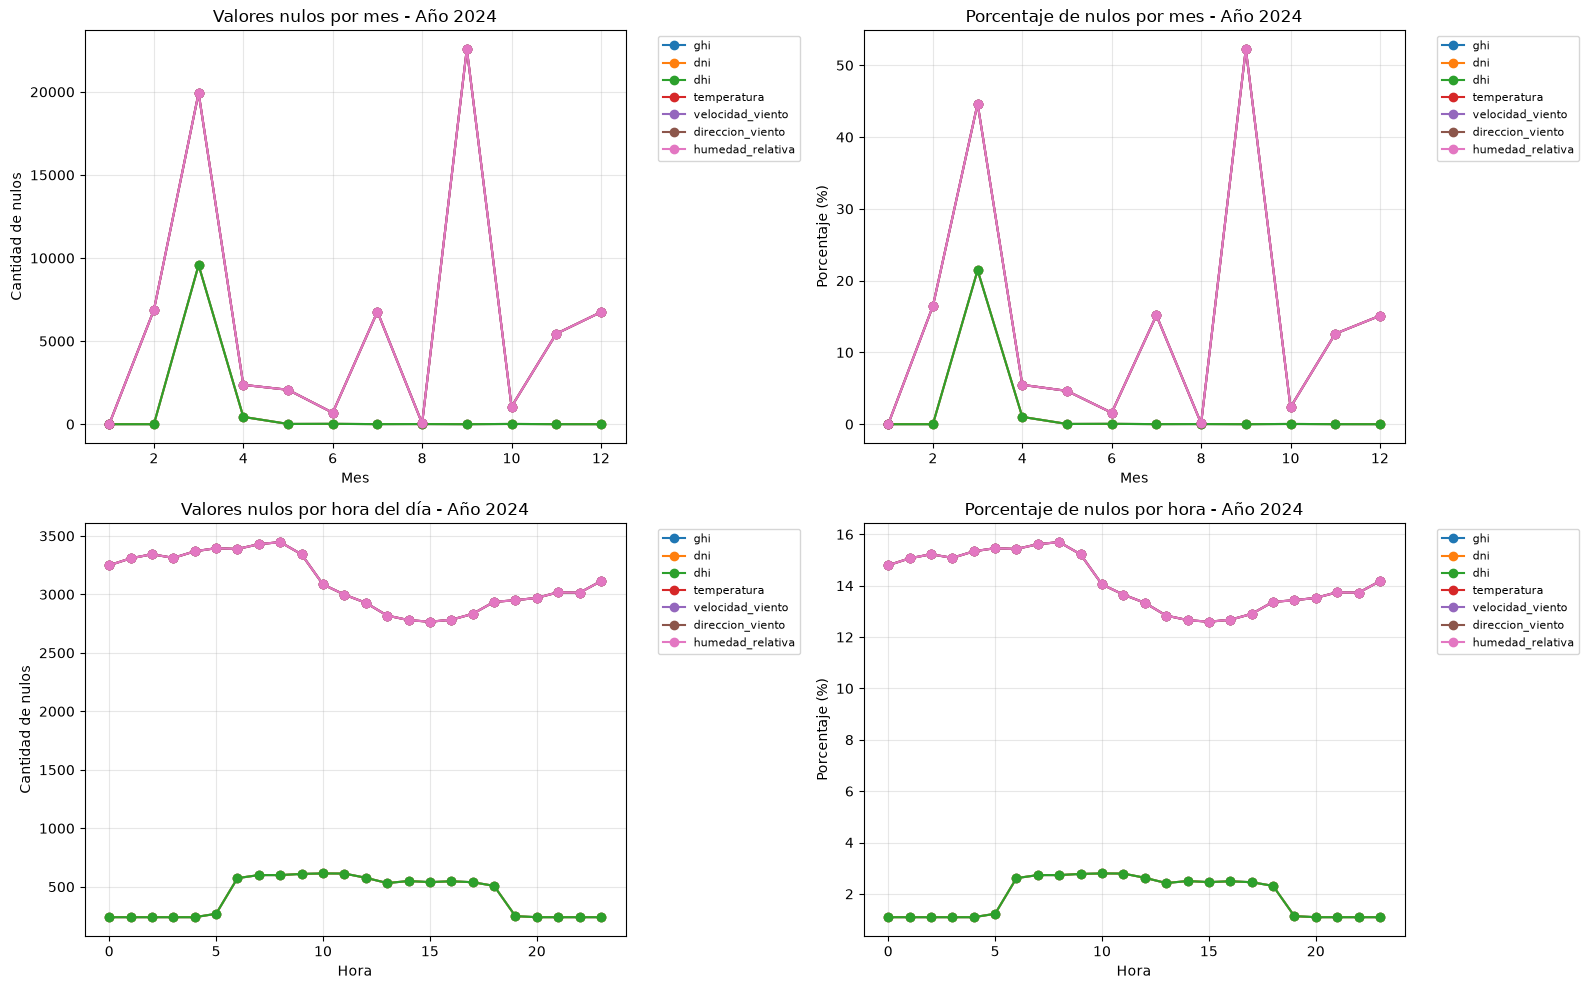

In [54]:
analyze_missing_temporal_patterns(df, numeric_columns_without_elevacion, year=2024)

Los valores nulos son claramente más numerosos en 2024 que en 2023, especialmente en las variables meteorológicas, y se concentran en determinados meses, lo que puede indicar interrupciones puntuales en el sistema de adquisición.

En las variables de irradiancia, el porcentaje de nulos aumenta durante las horas diurnas, cuando el sol ya ha salido. Estos valores son especialmente perjudiciales, ya que coinciden con el periodo en el que la irradiancia contiene información relevante. En cambio, los nulos registrados durante la noche pueden imputarse de forma sencilla con un valor igual a cero.

Para las variables meteorológicas, se van a obtener los valores faltantes, y los valores para los casos donde las variables sean negativas (como se ha visto en el caso de la temperatura), mediante el uso de [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api?utm_source=chatgpt.com), dejando el resto de valores tal y como vienen al provenir de la fuente original. 

Open-Meteo dispone de una API histórica sin necesidad de API key y permite descargar, para unas coordenadas concretas, variables meteorológicas.

In [74]:
import requests

latitude = 37.3891
longitude = -5.9845

variables = [
    "temperature_2m",
    "relative_humidity_2m",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
]

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": "2023-01-01",
    "end_date": "2024-12-31",
    "hourly": ",".join(variables),
    "timezone": "Europe/Madrid"
}

response = requests.get(url, params=params, timeout=60)
response.raise_for_status()

data = response.json()["hourly"]
df_weather = pd.DataFrame(data)

df_weather['wind_speed_10m'] = round(df_weather['wind_speed_10m']/3.6, 3) # Paso a m/s como en el dataset original
df_weather["time"] = pd.to_datetime(df_weather["time"])
df_weather = df_weather.set_index("time")

print(df_weather.shape)
df_weather.head()

(17544, 5)


,temperature_2m,relative_humidity_2m,cloud_cover,wind_speed_10m,wind_direction_10m
time,,,,,
2023-01-01 00:00:00,9.5,88,27,1.500,48
2023-01-01 01:00:00,9.4,88,19,1.639,47
2023-01-01 02:00:00,8.9,87,1,1.528,67
2023-01-01 03:00:00,9.0,85,95,1.528,32
2023-01-01 04:00:00,8.4,87,85,1.806,34


In [72]:
df[['fecha', 'temperatura', 'humedad_relativa', 'velocidad_viento', 'direccion_viento']].head()

,fecha,temperatura,humedad_relativa,velocidad_viento,direccion_viento
0,2023-01-01 00:00:00,10.0,77.0,1.050,117.750
1,2023-01-01 00:01:00,10.0,77.0,1.333,311.500
2,2023-01-01 00:02:00,10.0,77.0,1.100,256.417
3,2023-01-01 00:03:00,10.0,77.0,1.333,290.417
4,2023-01-01 00:04:00,10.0,77.0,1.058,333.667


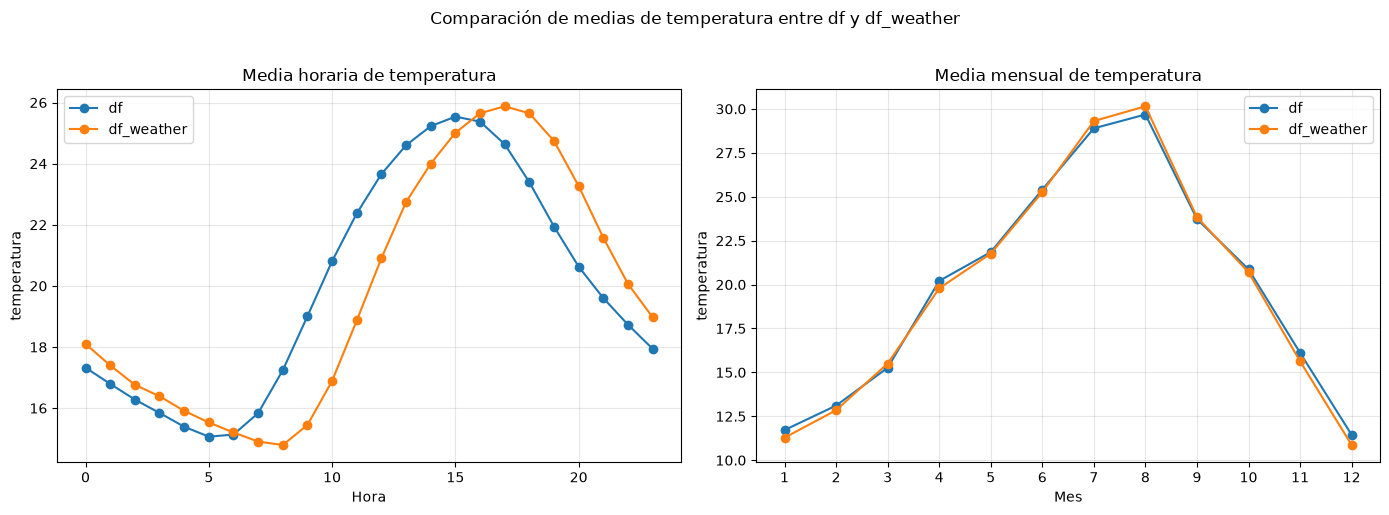

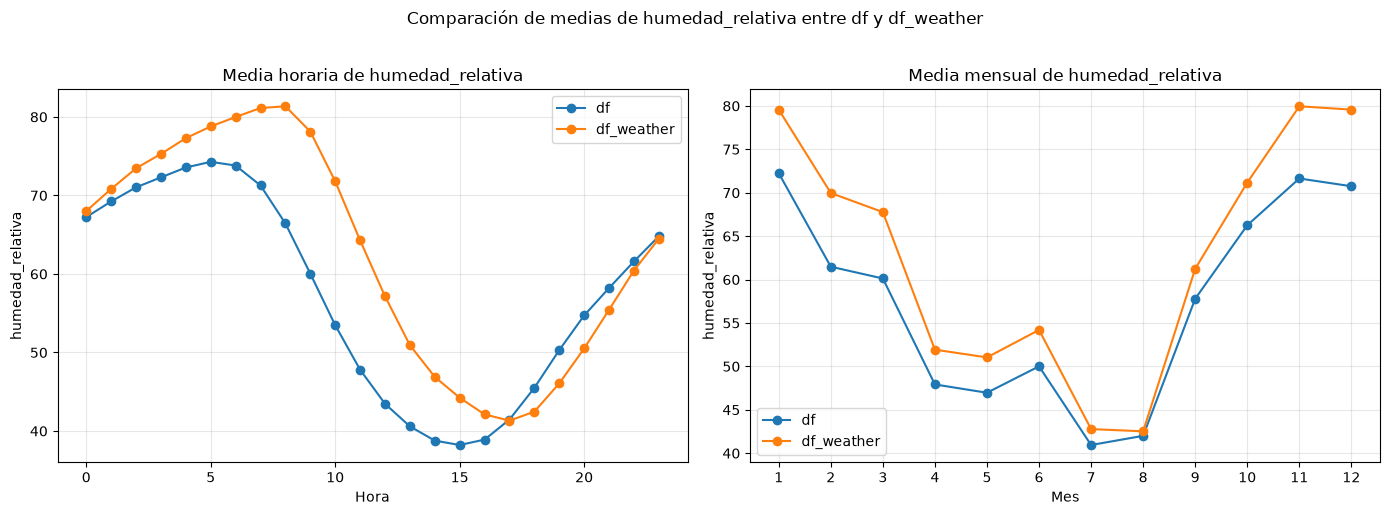

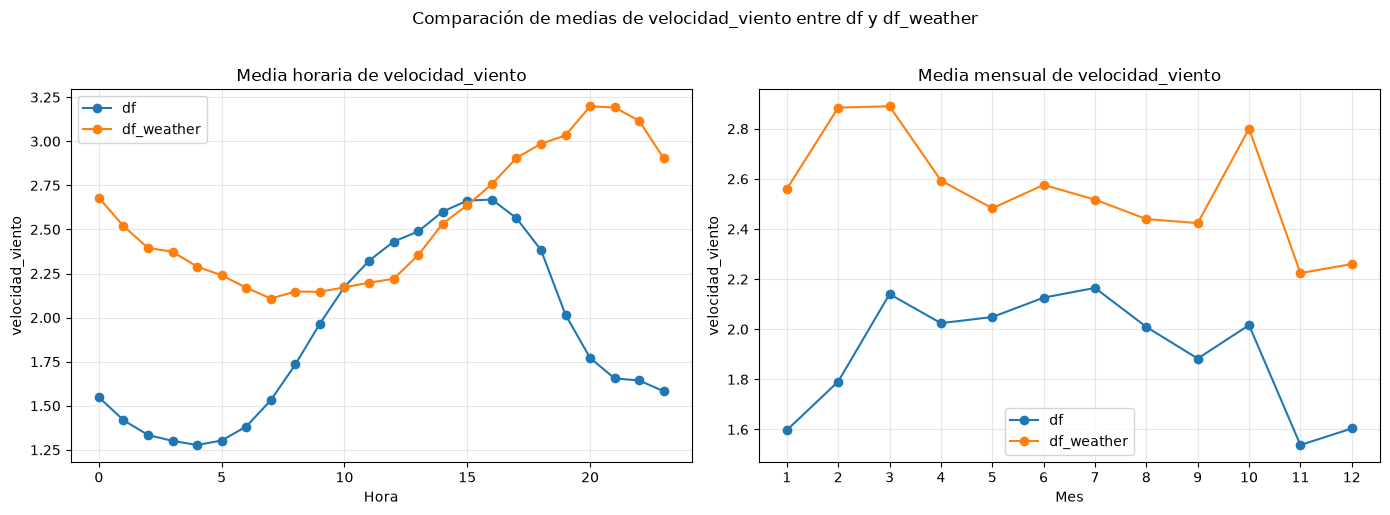

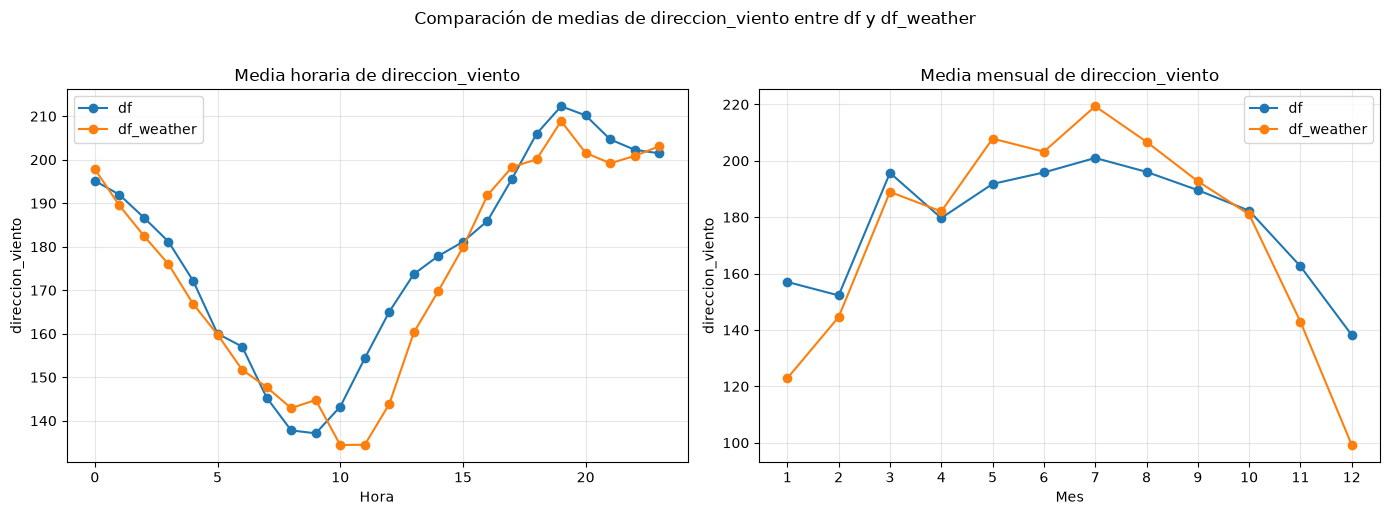

In [75]:
weather_map = {
    "temperatura": "temperature_2m",
    "humedad_relativa": "relative_humidity_2m",
    "velocidad_viento": "wind_speed_10m",
    "direccion_viento": "wind_direction_10m",
}

df_weather_plot = df_weather.copy()
df_weather_plot["mes"] = df_weather_plot.index.month
df_weather_plot["hora"] = df_weather_plot.index.hour

for col_es, col_en in weather_map.items():
    df_month = df.groupby("mes")[col_es].mean()
    df_hour = df.groupby("hora")[col_es].mean()
    weather_month = df_weather_plot.groupby("mes")[col_en].mean()
    weather_hour = df_weather_plot.groupby("hora")[col_en].mean()

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(df_hour.index, df_hour.values, label="df", marker="o")
    plt.plot(weather_hour.index, weather_hour.values, label="df_weather", marker="o")
    plt.title(f"Media horaria de {col_es}")
    plt.xlabel("Hora")
    plt.ylabel(col_es)
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(df_month.index, df_month.values, label="df", marker="o")
    plt.plot(weather_month.index, weather_month.values, label="df_weather", marker="o")
    plt.title(f"Media mensual de {col_es}")
    plt.xlabel("Mes")
    plt.ylabel(col_es)
    plt.xticks(range(1, 13))
    plt.legend()
    plt.grid(alpha=0.3)

    plt.suptitle(f"Comparación de medias de {col_es} entre df y df_weather", y=1.02)
    plt.tight_layout()
    plt.show()

Vemos que los valores obtenidos mediante la API no son las mismas que las obtenidas en el dataset, por lo que se busca otra alternativa. Esta alternativa va a ser utilizar la API de la AEMET, [Aemet OpenData](https://opendata.aemet.es/centrodedescargas/inicio) 

In [76]:
import os
import requests
import pandas as pd

from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("API_KEY")

if not API_KEY:
    raise ValueError(
        "No se encontró API_KEY. Comprueba que existe en el archivo .env"
    )

BASE_URL = "https://opendata.aemet.es/opendata/api"


def get_aemet_data(endpoint: str):
    """
    Consulta un endpoint de AEMET OpenData y descarga los datos asociados.

    Parameters
    ----------
    endpoint : str
        Endpoint relativo de AEMET, sin BASE_URL.

    Returns
    -------
    dict | list
        Datos devueltos por AEMET.
    """
    url = f"{BASE_URL}/{endpoint.lstrip('/')}"

    response = requests.get(
        url,
        params={"api_key": API_KEY},
        timeout=60
    )
    response.raise_for_status()

    metadata = response.json()

    if metadata.get("estado") != 200:
        raise RuntimeError(
            f"Error de AEMET: {metadata.get('descripcion', metadata)}"
        )

    data_url = metadata.get("datos")

    if not data_url:
        raise RuntimeError(
            f"AEMET no devolvió una URL de datos: {metadata}"
        )

    data_response = requests.get(data_url, timeout=60)
    data_response.raise_for_status()

    return data_response.json()

In [77]:
stations_data = get_aemet_data(
    "valores/climatologicos/"
    "inventarioestaciones/todasestaciones/"
)

df_stations = pd.DataFrame(stations_data)

print(df_stations.columns)
print(df_stations.head())

Index(['latitud', 'provincia', 'altitud', 'indicativo', 'nombre', 'indsinop',
       'longitud'],
      dtype='str')
   latitud      provincia altitud indicativo               nombre indsinop  \
0  394924N  ILLES BALEARS     490      B013X        ESCORCA, LLUC    08304   
1  394744N       BALEARES       5      B051A       SÓLLER, PUERTO    08316   
2  394121N  ILLES BALEARS      60      B087X          BANYALBUFAR            
3  393446N       BALEARES      52      B103B   ANDRATX - SANT ELM            
4  393305N       BALEARES      50      B158X  CALVIÀ, ES CAPDELLÀ            

  longitud  
0  025309E  
1  024129E  
2  023046E  
3  022208E  
4  022759E  


In [78]:
df_sevilla_stations = df_stations[
    df_stations["provincia"]
    .astype(str)
    .str.upper()
    .eq("SEVILLA")
].copy()

columns_to_show = [
    column for column in [
        "indicativo",
        "nombre",
        "provincia",
        "altitud",
        "latitud",
        "longitud"
    ]
    if column in df_sevilla_stations.columns
]

df_sevilla_stations[columns_to_show]

,indicativo,nombre,provincia,altitud,latitud,longitud
597,5612B,LA RODA DE ANDALUCÍA,SEVILLA,410,371140N,044612W
598,5612X,LORA DE ESTEPA,SEVILLA,450,371613N,044937W
601,5641X,ÉCIJA,SEVILLA,130,373058N,050506W
602,5654X,LA PUEBLA DE LOS INFANTES,SEVILLA,200,374712N,052216W
603,5656,FUENTES DE ANDALUCÍA,SEVILLA,165,372950N,052559W
604,5702X,CARMONA,SEVILLA,50,373356N,054426W
605,5704B,CAZALLA DE LA SIERRA,SEVILLA,550,375535N,054611W
606,5726X,GUADALCANAL,SEVILLA,720,380558N,054909W
607,5733X,ALMADÉN DE LA PLATA,SEVILLA,450,374728N,060430W
609,5783,SEVILLA AEROPUERTO,SEVILLA,34,372500N,055245W


In [84]:
station_id = "5790Y" # Estación de Sevilla, Tablada

In [85]:
import pandas as pd


def download_aemet_daily_period(
    station_id: str,
    start_date: str,
    end_date: str
) -> pd.DataFrame:
    """
    Descarga valores climatológicos diarios de AEMET dividiendo
    automáticamente el intervalo en bloques inferiores a seis meses.
    """

    start = pd.Timestamp(start_date)
    end = pd.Timestamp(end_date)

    dataframes = []
    current_start = start

    while current_start <= end:
        # Se resta un día para evitar superar exactamente los seis meses
        current_end = min(
            current_start + pd.DateOffset(months=6) - pd.Timedelta(days=1),
            end
        )

        endpoint = (
            "valores/climatologicos/diarios/datos/"
            f"fechaini/{current_start:%Y-%m-%d}T00:00:00UTC/"
            f"fechafin/{current_end:%Y-%m-%d}T23:59:59UTC/"
            f"estacion/{station_id}"
        )

        print(
            f"Descargando desde {current_start.date()} "
            f"hasta {current_end.date()}"
        )

        chunk_data = get_aemet_data(endpoint)
        chunk_df = pd.DataFrame(chunk_data)

        if not chunk_df.empty:
            dataframes.append(chunk_df)

        current_start = current_end + pd.Timedelta(days=1)

    if not dataframes:
        return pd.DataFrame()

    df = pd.concat(dataframes, ignore_index=True)

    if "fecha" in df.columns:
        df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

        df = (
            df
            .drop_duplicates(
                subset=["fecha", "indicativo"],
                keep="last"
            )
            .sort_values("fecha")
            .reset_index(drop=True)
        )

    return df

In [86]:
df_aemet = download_aemet_daily_period(
    station_id=station_id,
    start_date="2023-01-01",
    end_date="2024-12-31"
)

print(df_aemet.shape)
print(df_aemet.columns.tolist())
df_aemet.head()

Descargando desde 2023-01-01 hasta 2023-06-30
Descargando desde 2023-07-01 hasta 2023-12-31
Descargando desde 2024-01-01 hasta 2024-06-30
Descargando desde 2024-07-01 hasta 2024-12-31
(731, 22)
['fecha', 'indicativo', 'nombre', 'provincia', 'altitud', 'tmed', 'prec', 'tmin', 'horatmin', 'tmax', 'horatmax', 'dir', 'velmedia', 'racha', 'horaracha', 'hrMedia', 'hrMax', 'horaHrMax', 'hrMin', 'horaHrMin', 'pintMax', 'horaPIntMax']


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,...,velmedia,racha,horaracha,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,pintMax,horaPIntMax
0,2023-01-01,5790Y,"SEVILLA, TABLADA",SEVILLA,9,"12,0","5,4","7,6",07:06,"16,3",...,"0,6","5,3",23:50,76,93,22:40,59,13:00,"0,0",NaN
1,2023-01-02,5790Y,"SEVILLA, TABLADA",SEVILLA,9,"12,4","5,0","10,5",00:01,"14,3",...,"0,8","3,9",Varias,97,98,Varias,89,00:10,"8,4",07:45
2,2023-01-03,5790Y,"SEVILLA, TABLADA",SEVILLA,9,"13,3","0,0","7,6",07:48,"19,0",...,"1,4","5,3",12:40,80,98,00:00,63,11:50,"0,0",NaN
3,2023-01-04,5790Y,"SEVILLA, TABLADA",SEVILLA,9,"14,4","0,0","8,6",07:56,"20,3",...,"1,4","5,0",14:00,79,96,08:10,63,14:00,"0,0",NaN
4,2023-01-05,5790Y,"SEVILLA, TABLADA",SEVILLA,9,"14,2","0,0","8,1",23:47,"20,4",...,"0,8","5,0",05:20,78,96,08:00,57,15:20,"0,0",NaN


In [87]:
non_numeric_columns = {
    "fecha",
    "indicativo",
    "nombre",
    "provincia"
}

for column in df_aemet.columns:
    if column not in non_numeric_columns:
        df_aemet[column] = pd.to_numeric(
            df_aemet[column]
            .astype(str)
            .str.replace(",", ".", regex=False),
            errors="coerce"
        )

In [88]:
df_aemet.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   fecha        731 non-null    datetime64[us]
 1   indicativo   731 non-null    str           
 2   nombre       731 non-null    str           
 3   provincia    731 non-null    str           
 4   altitud      731 non-null    int64         
 5   tmed         727 non-null    float64       
 6   prec         714 non-null    float64       
 7   tmin         727 non-null    float64       
 8   horatmin     0 non-null      float64       
 9   tmax         727 non-null    float64       
 10  horatmax     0 non-null      float64       
 11  dir          728 non-null    float64       
 12  velmedia     731 non-null    float64       
 13  racha        728 non-null    float64       
 14  horaracha    0 non-null      float64       
 15  hrMedia      731 non-null    int64         
 16  hrMax        727 no

In [63]:
from datetime import datetime
import meteostat as ms

# Coordenadas aproximadas de Sevilla
sevilla = ms.Point(
    latitude=37.3891,
    longitude=-5.9845,
    elevation=7
)

start = datetime(2023, 1, 1)
end = datetime(2024, 12, 31, 23, 59)

# Buscar estaciones cercanas
stations = ms.stations.nearby(sevilla, limit=10)

print(stations[
    ["name", "country", "region", "latitude", "longitude", "elevation"]
])

                            name country region  latitude  longitude  \
id                                                                     
08390          Sevilla / Tablada      ES     AN   37.3667    -6.0000   
08391        Sevilla / San Pablo      ES     AN   37.4167    -5.9000   
69669  Moron / Cortijo de Palomo      ES     AN   37.1667    -5.6167   
08397       Moron De La Frontera      ES     AN   37.1500    -5.6167   

       elevation  
id                
08390         14  
08391         34  
69669         87  
08397         87  


In [65]:
station_id = stations.index[0]

print("Estación seleccionada:", station_id)
print(stations.iloc[0])

Estación seleccionada: 08390
name         Sevilla / Tablada
country                     ES
region                      AN
latitude               37.3667
longitude                 -6.0
elevation                   14
timezone         Europe/Madrid
distance                2842.5
Name: 08390, dtype: object


In [66]:
ts = ms.hourly(
    station_id,
    start=start,
    end=end,
    timezone="Europe/Madrid"
)

df_meteostat = ts.fetch()

if df_meteostat is None:
    raise RuntimeError("Meteostat no ha devuelto ningún DataFrame")

if df_meteostat.empty:
    raise ValueError(
        f"No hay datos horarios disponibles para la estación {station_id}"
    )

print(df_meteostat.shape)
print(df_meteostat.columns)
print(df_meteostat.head())

(17544, 11)
Index(['temp', 'rhum', 'prcp', 'snwd', 'wdir', 'wspd', 'wpgt', 'pres', 'tsun',
       'cldc', 'coco'],
      dtype='str')
                           temp  rhum  prcp  snwd  wdir  wspd  wpgt    pres  \
time                                                                          
2023-01-01 00:00:00+01:00  10.0    78  <NA>  <NA>    40   7.4  13.0  1026.7   
2023-01-01 01:00:00+01:00   9.2    78  <NA>  <NA>    32   7.4  13.0  1026.1   
2023-01-01 02:00:00+01:00   8.7    79  <NA>  <NA>    34   7.4  13.0  1026.2   
2023-01-01 03:00:00+01:00   7.2    85  <NA>  <NA>    36   9.3  14.8  1025.7   
2023-01-01 04:00:00+01:00   6.6    86  <NA>  <NA>    35   7.4  14.8  1025.3   

                           tsun  cldc  coco  
time                                         
2023-01-01 00:00:00+01:00  <NA>     3     2  
2023-01-01 01:00:00+01:00  <NA>     3     2  
2023-01-01 02:00:00+01:00  <NA>     3     2  
2023-01-01 03:00:00+01:00  <NA>     3     2  
2023-01-01 04:00:00+01:00  <NA>     